In [1]:
import logging

import os
from pathlib import Path
import functools

import numpy as np
import matplotlib.pyplot as plt

logger = logging.getLogger('FIT PNG')

# remove warning on my mac -> deactivate on NERSC.
os.environ['OMPI_MCA_btl'] = 'self,tcp'  # deactivate shmem

# disable jax warning:
for logger_name in ['jax._src.xla_bridge', 'jax._src.distributed', 'jax._src.interpreters.pxla', 'jax._src.dispatch', 
                    'jax._src.compiler', 'jax._src.cache_key', 'jax._src.compilation_cache', 'matplotlib.ticker']:
    logging.getLogger(logger_name).setLevel(logging.ERROR)

# Remove warning from jax
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

from tools import read_data, rebin_data, get_observable_and_likelihood, build_total_likelihood, plot_observables, run_profiler, run_mcmc, plot_triangle

from clustering_statistics import setup_logging
 
from mpi4py import MPI
setup_logging(level=(logging.INFO if MPI.COMM_WORLD.rank == 0 else logging.ERROR))

# root = '/global/cfs/cdirs/desi/science/cai/desi-clustering/'
root = '/Users/edmond/Work/data/desi-clustering/' 

data_dir =  root + 'dr2/summary_statistics/local_png/base/desi-data/loa-v1/v2/fNL/blinded'
mocks_dir = root + 'dr2/summary_statistics/local_png/base/'

logger.info(f'Load data from: {data_dir} and mocks from: {mocks_dir}')

[000000.00] [0/1] 07-07 18:00  FIT PNG                   INFO     Load data from: /Users/edmond/Work/data/desi-clustering/dr2/summary_statistics/local_png/base/desi-data/loa-v1/v2/fNL/blinded and mocks from: /Users/edmond/Work/data/desi-clustering/dr2/summary_statistics/local_png/base/


In [2]:
def propose_fiducial(kmin=1e-3, kmax=0.08, region='GCcomb', use_ell2=True):
    propose_fiducial = {}

    propose_fiducial['LRG'] = {'weight_type': 'default-fkp-oqe', 'zrange': (0.4, 1.1), 'region': region, 
                               'window_extra': 'RIC+AMR', 'tracer_window': 'LRG', 'tracer_mocks': 'LRG', 'weight_type_mocks': 'default-fkp-oqe',
                               'use_ell2': use_ell2, 'kmin': kmin, 'kmax': kmax, 'kmin_ell2': kmin, 'kmax_ell2': kmax}
    propose_fiducial['ELG'] = {'weight_type': 'default-fkp-oqe', 'zrange': (0.8, 1.6), 'region': region, 
                               'window_extra': 'RIC+AMR', 'tracer_window': 'ELG', 'tracer_mocks': 'ELGnotqso', 'weight_type_mocks': 'default-fkp-oqe',
                               'use_ell2': use_ell2, 'kmin': kmin, 'kmax': kmax, 'kmin_ell2': kmin, 'kmax_ell2': kmax}  #6e-3
    propose_fiducial['QSO'] = {'weight_type': 'default-fkp-oqe', 'zrange': (0.8, 3.5), 'region': region, 
                               'window_extra': 'RIC+AMR', 'tracer_window': 'QSO', 'tracer_mocks': 'QSO', 'weight_type_mocks': 'default-fkp-oqe',
                               'use_ell2': use_ell2, 'kmin': kmin, 'kmax': kmax, 'kmin_ell2': kmin, 'kmax_ell2': kmax}   
    
    propose_fiducial['LRGxQSO'] = {'weight_type': 'default-fkp-oqe', 'zrange': (0.8, 1.1), 'region': region, 
                                   'window_extra': 'RIC+AMR', 'tracer_window': 'LRGxQSO', 'tracer_mocks': 'LRGxQSO', 'weight_type_mocks': 'default-fkp-oqe',
                                   'use_ell2': use_ell2, 'kmin': kmin, 'kmax': kmax, 'kmin_ell2': kmin, 'kmax_ell2': kmax}   
    propose_fiducial['LRGxELG'] = {'weight_type': 'default-fkp-oqe', 'zrange': (0.8, 1.1), 'region': region, 
                                   'window_extra': 'RIC+AMR', 'tracer_window': 'LRGxELG', 'tracer_mocks': 'LRGxELGnotqso', 'weight_type_mocks': 'default-fkp-oqe',
                                   'use_ell2': use_ell2, 'kmin': kmin, 'kmax': kmax, 'kmin_ell2': kmin, 'kmax_ell2': kmax}   
    propose_fiducial['ELGxQSO'] = {'weight_type': 'default-fkp-oqe', 'zrange': (0.8, 1.6), 'region': region, 
                                   'window_extra': 'RIC+AMR', 'tracer_window': 'ELGxQSO', 'tracer_mocks': 'ELGnotqsoxQSO', 'weight_type_mocks': 'default-fkp-oqe',
                                   'use_ell2': use_ell2, 'kmin': kmin, 'kmax': kmax, 'kmin_ell2': kmin, 'kmax_ell2': kmax}   
    
    # when sort tracer name, ELG arrive first, so it is convienient to have it here as well 
    propose_fiducial['ELGxLRG'] = propose_fiducial['LRGxELG']
      
    return propose_fiducial

In [67]:
regions = ['GCcomb']
tracers_to_read = ['QSO']

pks = {region: {} for region in regions}
windows = {region: {} for region in regions}
covs = {region: {} for region in regions}
mocks = {region: {} for region in regions}
zeffs = {region: {} for region in regions}

for region in regions:
    for tracer in tracers_to_read:
        # reload fiducial because we will overwrite things here ... 
        fiducial = propose_fiducial(kmin=3e-3, kmax=0.08, region=region)

        short_tracer = tracer.replace('_zcmb', '')
        short_tracer = short_tracer.replace('notqso', '')

        if tracer == 'LRG_zcmb':
            fiducial[short_tracer]['tracer_window'] = 'LRG_zcmb'
            fiducial[short_tracer]['weight_type'] = 'default-fkp-oqe-wsys-imlin_finezbin_allebvcmb'
        if tracer == 'LRG_zcmbxQSO_zcmb':
            fiducial[short_tracer]['tracer_window'] = 'LRG_zcmbxQSO_zcmb'
            fiducial[short_tracer]['weight_type'] = 'default-fkp-oqe-wsys-imlin_finezbin_allebvcmbxdefault-fkp-oqe'

        pk, window, cov, mock = read_data(
            data_dir=data_dir,
            mocks_dir=mocks_dir,
            tracer=tracer,
            **fiducial[short_tracer],
        )

        pk, window, cov, mock = rebin_data(pk, window, cov, mock, tracer=tracer, **fiducial[short_tracer])

        if 'x' not in short_tracer:
            short_tracer = 'x'.join(2 * [short_tracer])

        pks[region][tracer] = pk
        windows[region][tracer] = window
        covs[region][tracer] = cov
        mocks[region][tracer] = mock

        zeffs[region][short_tracer] = {}
        zeffs[region][short_tracer][0] = windows[region][tracer].observable.get(0).attrs['zeff']
        try:
            zeffs[region][short_tracer][2] = windows[region][tracer].observable.get(2).attrs['zeff']
        except ValueError:
            pass

[001389.46] [0/1] 07-07 18:23  PNG fitting tools         INFO     Reading the data with weight_type='default-fkp-oqe' from /Users/edmond/Work/data/desi-clustering/dr2/summary_statistics/local_png/base/desi-data/loa-v1/v2/fNL/blinded/mesh2_spectrum_poles_QSO_z0.8-3.5_GCcomb_weight-default-fkp-oqe.h5
[001389.47] [0/1] 07-07 18:23  PNG fitting tools         INFO     Reading the window with tracer_window='QSO', weight_type='default-fkp-oqe',window_extra='RIC+AMR' from /Users/edmond/Work/data/desi-clustering/dr2/summary_statistics/local_png/base/desi-data/loa-v1/v2/fNL/blinded/window_mesh2_spectrum_poles_QSO_z0.8-3.5_GCcomb_weight-default-fkp-oqe_RIC+AMR.h5
[001389.50] [0/1] 07-07 18:23  PNG fitting tools         INFO     Reading nmocks=1000 for tracer='QSO' with tracer_mocks='QSO' weight_type_mocks='default-fkp-oqe'.


In [68]:
import lsstypes 
data = pks['GCcomb']['QSO'].get(ells=[0])

wmatrix = windows['GCcomb']['QSO'].at.observable.match(data)

covariance = lsstypes.cov([mock.match(data) for mock in mocks['GCcomb']['QSO']]).value()
correction_covariance = {'correction': 'hartlap2007+percival2014', 'nobs': 1000}

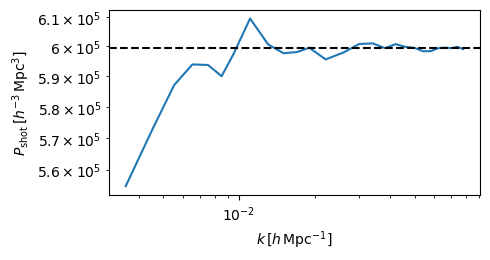

In [69]:
#template_sn = lsstypes.read('/Users/edmond/Work/data/desi-clustering/dr2/summary_statistics/local_png/base/desi-data/loa-v1/v2/fNL/blinded/shotnoise_mesh2_spectrum_poles_fm_LRG_z0.4-1.1_GCcomb_weight-default-fkp-oqe_RIC+AMR.h5')

template_sn = lsstypes.read('/Users/edmond/Work/data/desi-clustering/dr2/summary_statistics/local_png/base/desi-data/loa-v1/v2/fNL/blinded/shotnoise_mesh2_spectrum_poles_fm_QSO_z0.8-3.5_GCcomb_weight-default-fkp-oqe_RIC+AMR.h5')

template_sn = template_sn.match(data)

plt.figure(figsize=(5,2.7))
plt.loglog(template_sn.get(0).k, template_sn.get(0).value())
plt.axhline(template_sn.get(0).value()[-4], ls='--', color='k')
plt.xlabel(r'$k\,[h\,{\rm Mpc}^{-1}]$')
plt.ylabel(r'$P_{\rm shot}\,[h^{-3}\,{\rm Mpc}^{3}]$')
plt.tight_layout()
plt.show()

[001397.27] [0/1] 07-07 18:23  ObservablesGaussianLikelihood INFO     Covariance matrix with 27 points built from 1000 observations.
[001397.27] [0/1] 07-07 18:23  ObservablesGaussianLikelihood INFO     ...resulting in a Hartlap 2007 factor of 0.9720.
[001397.27] [0/1] 07-07 18:23  ObservablesGaussianLikelihood INFO     Covariance matrix with 27 points and 4 parameters built from 1000 observations.
[001397.27] [0/1] 07-07 18:23  ObservablesGaussianLikelihood INFO     ...resulting in a Percival 2014 factor of 1.0185.
[001397.29] [0/1] 07-07 18:23  Profiler                  INFO     Varied parameters: ['QSO.b1', 'QSO.sigmas', 'fnl_loc', 'QSO.sn2']
[001397.76] [0/1] 07-07 18:23  FIT PNG                   INFO     
+-------------------------+-------+-------+
| chi2 = 31.68 / (27 - 4) | best  | error |
+-------------------------+-------+-------+
|         QSO.b1          | 1.809 | 0.024 |
|       QSO.sigmas        |  5.9  |  1.1  |
|         fnl_loc         |  -5   |  19   |
|         QSO.s

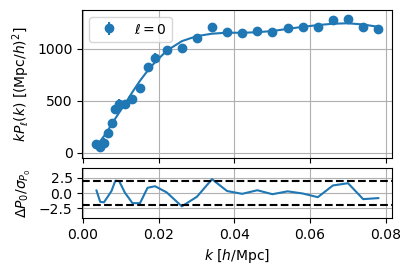

In [70]:
from desilike.theories.galaxy_clustering import FixedSpectrum2Template, PNGTracerSpectrum2Poles
from desilike.observables.galaxy_clustering import Spectrum2PolesObservable
from desilike.likelihoods import ObservablesGaussianLikelihood
from desilike import get_params
from cosmoprimo.fiducial import DESI
from desilike.base import compile, params
from desilike import Posterior, compile
from desilike.profilers import Profiler, Minuit


template = FixedSpectrum2Template(fiducial=DESI(engine='camb'), engine='camb', z=0.8)
theory = PNGTracerSpectrum2Poles(template=template, mode="b-p", tracers='QSO')

# Fix some parameters:
params = get_params(theory)
params['fnl_loc'].update(value=0.0, fixed=False)
params['QSO.p'].update(value=1, fixed=True)
params['QSO.sn0'].update(value=0, fixed=True)

theory.update(params=params)

obs = Spectrum2PolesObservable(name='test', data=data, window=wmatrix, theory=theory,
                               templates=[({'name': 'QSO.sn2', 'value': 0.0, 'fixed': False}, template_sn.value() - template_sn.value()[-4])])

likelihood = ObservablesGaussianLikelihood(observables=obs, covariance=covariance, 
                                           correct_covariance=correction_covariance, scale_covariance=1)

posterior = compile(Posterior(likelihood=likelihood))
profiler = Profiler(posterior, kernel=Minuit(), rng=7)
profiles = profiler.maximize(niterations=10)
logger.info(f'\n{profiles.to_stats(tablefmt="pretty")}')
best = profiles.choice(index='argmax', squeeze=True).select(input=True).best

# To set internal arrays
compile(likelihood)(best)

_ = obs.plot(figsize=(4, 2.7))

[001400.23] [0/1] 07-07 18:23  ObservablesGaussianLikelihood INFO     Covariance matrix with 27 points built from 1000 observations.
[001400.23] [0/1] 07-07 18:23  ObservablesGaussianLikelihood INFO     ...resulting in a Hartlap 2007 factor of 0.9720.
[001400.23] [0/1] 07-07 18:23  ObservablesGaussianLikelihood INFO     Covariance matrix with 27 points and 4 parameters built from 1000 observations.
[001400.23] [0/1] 07-07 18:23  ObservablesGaussianLikelihood INFO     ...resulting in a Percival 2014 factor of 1.0185.
[001400.24] [0/1] 07-07 18:23  Profiler                  INFO     Varied parameters: ['QSO.b1', 'QSO.sigmas', 'QSO.sn0', 'fnl_loc']
[001400.61] [0/1] 07-07 18:23  FIT PNG                   INFO     
+-------------------------+-------+-------+
| chi2 = 31.63 / (27 - 4) | best  | error |
+-------------------------+-------+-------+
|         QSO.b1          | 1.779 | 0.073 |
|       QSO.sigmas        |  7.9  |  5.3  |
|         QSO.sn0         | 0.13  | 0.33  |
|         fnl_l

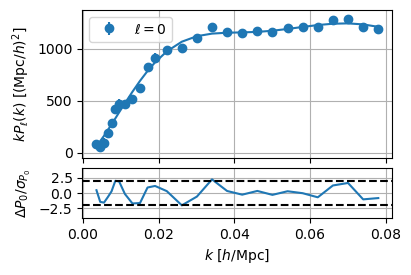

In [71]:
# Fix some parameters:
params = get_params(theory)
params['fnl_loc'].update(value=0.0, fixed=False)
params['QSO.p'].update(value=1, fixed=True)
params['QSO.sn0'].update(value=0, fixed=False)

theory.update(params=params)

obs = Spectrum2PolesObservable(name='test', data=data, window=wmatrix, theory=theory,
                               templates=[({'name': 'QSO.sn2', 'value': 0.0, 'fixed': True}, template_sn.value() - template_sn.value()[-4])])

likelihood = ObservablesGaussianLikelihood(observables=obs, covariance=covariance, 
                                           correct_covariance=correction_covariance, scale_covariance=1)

posterior = compile(Posterior(likelihood=likelihood))
profiler = Profiler(posterior, kernel=Minuit(), rng=7)
profiles2 = profiler.maximize(niterations=10)
logger.info(f'\n{profiles2.to_stats(tablefmt="pretty")}')
best = profiles2.choice(index='argmax', squeeze=True).select(input=True).best

# To set internal arrays
compile(likelihood)(best)

_ = obs.plot(figsize=(4, 2.7))

In [72]:
print(f'\n{profiles2.to_stats(tablefmt="pretty")}')

print(f'\n{profiles.to_stats(tablefmt="pretty")}')


+-------------------------+-------+-------+
| chi2 = 31.63 / (27 - 4) | best  | error |
+-------------------------+-------+-------+
|         QSO.b1          | 1.779 | 0.073 |
|       QSO.sigmas        |  7.9  |  5.3  |
|         QSO.sn0         | 0.13  | 0.33  |
|         fnl_loc         |  -2   |  18   |
+-------------------------+-------+-------+

+-------------------------+-------+-------+
| chi2 = 31.68 / (27 - 4) | best  | error |
+-------------------------+-------+-------+
|         QSO.b1          | 1.809 | 0.024 |
|       QSO.sigmas        |  5.9  |  1.1  |
|         QSO.sn0         |       |       |
|         fnl_loc         |  -5   |  19   |
|         QSO.sn2         | -0.05 | 0.14  |
+-------------------------+-------+-------+
